In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

%matplotlib inline

In [158]:
EXAMPLE_DATASET = {
    "dataset": "aakash50897/churn-modellingcsv",
    "file": "Churn_Modelling.csv",
    "redundant_columns": ["RowNumber", "CustomerId", "Surname"],
    "predicted_column": "Exited"
}

CHOSEN_DATASET = {
    "dataset": "amineipad/antenna-performance-and-fault-detection-dataset",
    "file": "antenna_fault.csv",
    "redundant_columns": ["BT Fault", "BT Status"],
    "predicted_column": "WiFi Status"
}

In [159]:
TARGET_DATASET = CHOSEN_DATASET

DATASET = TARGET_DATASET["dataset"]
DOWNLOAD_PATH = f"data/{TARGET_DATASET['dataset']}"
DATASET_FILE = TARGET_DATASET["file"]
REDUNDANT_COLUMNS = TARGET_DATASET.get("redundant_columns", [])
PREDICTED_COLUMN = TARGET_DATASET.get("predicted_column", None)

TEST_SIZE = 0.3
RANDOM_STATE = 101

In [160]:
df_path = kh.dataset_download(DATASET, output_dir=DOWNLOAD_PATH)
df = pd.read_csv(f"{df_path}/{DATASET_FILE}")

In [161]:
df.head()

,Length,Width,Height,Permittivity,Conductivity,Bend,Feed,S11,VSWR,Gain,Efficiency,Bandwidth,WiFi Fault,BT Fault,WiFi Status,BT Status,epsilon_r
0,46.72,38.62,1.46,1.51,12210.65,0.56,-10.27,-7.09,3.41,5.09,62.26,102.74,Cracks,Cracks,Fault,Fault,3.90
1,40.32,36.17,1.30,1.61,9589.73,0.48,-17.33,-7.92,2.47,5.17,66.61,96.06,Rupture_Coupure,No_Fault,Fault,Normal,3.03
2,43.84,35.89,1.17,1.53,4067.44,0.99,-11.95,-18.97,3.20,5.07,83.42,150.03,Bending,Strong_Flexion,Fault,Fault,3.65
3,43.77,39.46,1.26,1.88,13052.58,0.67,-10.07,-12.89,1.72,3.83,42.22,54.23,Body_Effect,Coupure,Fault,Fault,3.51
4,46.48,39.66,1.30,2.44,12682.11,1.08,-17.57,-22.94,1.44,3.48,77.39,93.00,Strong_Flexion,No_Fault,Fault,Normal,2.06


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2688 entries, 0 to 2687
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Length        2688 non-null   float64
 1   Width         2688 non-null   float64
 2   Height        2688 non-null   float64
 3   Permittivity  2688 non-null   float64
 4   Conductivity  2688 non-null   float64
 5   Bend          2688 non-null   float64
 6   Feed          2688 non-null   float64
 7   S11           2688 non-null   float64
 8   VSWR          2688 non-null   float64
 9   Gain          2688 non-null   float64
 10  Efficiency    2688 non-null   float64
 11  Bandwidth     2688 non-null   float64
 12  WiFi Fault    2688 non-null   str    
 13  BT Fault      2688 non-null   str    
 14  WiFi Status   2688 non-null   str    
 15  BT Status     2688 non-null   str    
 16  epsilon_r     2688 non-null   float64
dtypes: float64(13), str(4)
memory usage: 357.1 KB


In [163]:
df.describe()

,Length,Width,Height,Permittivity,Conductivity,Bend,Feed,S11,VSWR,Gain,Efficiency,Bandwidth,epsilon_r
count,2688.000000,2688.000000,2688.000000,2688.000000,2688.00000,2688.000000,2688.000000,2688.000000,2688.000000,2688.000000,2688.000000,2688.000000,2688.000000
mean,45.040193,34.834922,1.195725,1.985588,8852.08381,0.664364,-15.145205,-13.493899,2.667411,2.373166,59.510145,96.744650,2.741138
std,2.852841,2.881098,0.229659,0.286953,3543.21629,0.318201,5.775435,6.567709,0.905921,2.110233,18.207363,36.079177,0.735079
min,40.010000,30.010000,0.800000,1.500000,3013.71000,0.100000,-25.000000,-25.000000,1.000000,-0.990000,30.070000,40.040000,1.500000
25%,42.600000,32.337500,1.000000,1.740000,5649.95000,0.400000,-20.167500,-19.250000,1.880000,0.470000,42.870000,63.135000,2.130000
50%,45.060000,34.715000,1.200000,1.990000,8965.21000,0.690000,-15.180000,-13.380000,2.790000,2.390000,59.960000,96.900000,2.720000
75%,47.452500,37.210000,1.390000,2.230000,11990.47000,0.930000,-10.120000,-7.600000,3.470000,4.220000,75.610000,127.770000,3.380000
max,49.990000,39.990000,1.600000,2.500000,14998.36000,1.200000,-5.000000,-3.020000,4.000000,5.990000,89.960000,159.940000,4.000000


In [164]:
df = df.drop(columns=REDUNDANT_COLUMNS)
df.head()

,Length,Width,Height,Permittivity,Conductivity,Bend,Feed,S11,VSWR,Gain,Efficiency,Bandwidth,WiFi Fault,WiFi Status,epsilon_r
0,46.72,38.62,1.46,1.51,12210.65,0.56,-10.27,-7.09,3.41,5.09,62.26,102.74,Cracks,Fault,3.90
1,40.32,36.17,1.30,1.61,9589.73,0.48,-17.33,-7.92,2.47,5.17,66.61,96.06,Rupture_Coupure,Fault,3.03
2,43.84,35.89,1.17,1.53,4067.44,0.99,-11.95,-18.97,3.20,5.07,83.42,150.03,Bending,Fault,3.65
3,43.77,39.46,1.26,1.88,13052.58,0.67,-10.07,-12.89,1.72,3.83,42.22,54.23,Body_Effect,Fault,3.51
4,46.48,39.66,1.30,2.44,12682.11,1.08,-17.57,-22.94,1.44,3.48,77.39,93.00,Strong_Flexion,Fault,2.06


In [165]:
le = LabelEncoder()

In [166]:
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])
df.head()

/var/folders/8s/hnrlcfv16rdb1gwgppl6tj1c0000gn/T/ipykernel_45660/2534551035.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,Length,Width,Height,Permittivity,Conductivity,Bend,Feed,S11,VSWR,Gain,Efficiency,Bandwidth,WiFi Fault,WiFi Status,epsilon_r
0,46.72,38.62,1.46,1.51,12210.65,0.56,-10.27,-7.09,3.41,5.09,62.26,102.74,3,0,3.90
1,40.32,36.17,1.30,1.61,9589.73,0.48,-17.33,-7.92,2.47,5.17,66.61,96.06,6,0,3.03
2,43.84,35.89,1.17,1.53,4067.44,0.99,-11.95,-18.97,3.20,5.07,83.42,150.03,0,0,3.65
3,43.77,39.46,1.26,1.88,13052.58,0.67,-10.07,-12.89,1.72,3.83,42.22,54.23,1,0,3.51
4,46.48,39.66,1.30,2.44,12682.11,1.08,-17.57,-22.94,1.44,3.48,77.39,93.00,7,0,2.06


In [167]:
X = df.drop(columns=[PREDICTED_COLUMN])
y = df[PREDICTED_COLUMN]

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [169]:
scaler = StandardScaler()

In [170]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [171]:
model = Sequential()

In [172]:
model.add(Dense(units=10, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(units=10, activation="relu"))
model.add(Dense(units=1, activation="sigmoid"))

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [173]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 10)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

In [174]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [175]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8559 - loss: 0.4782 - val_accuracy: 0.9740 - val_loss: 0.3450
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.2782 - val_accuracy: 0.9876 - val_loss: 0.1933
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.1687 - val_accuracy: 0.9876 - val_loss: 0.1195
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.1190 - val_accuracy: 0.9876 - val_loss: 0.0875
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.0956 - val_accuracy: 0.9876 - val_loss: 0.0717
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.0829 - val_accuracy: 0.9876 - val_loss: 0.0629
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.0743 - val_accuracy: 0.9876 - val_loss: 0.0569
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.0680 - val_accuracy: 0.9876 - val_loss:

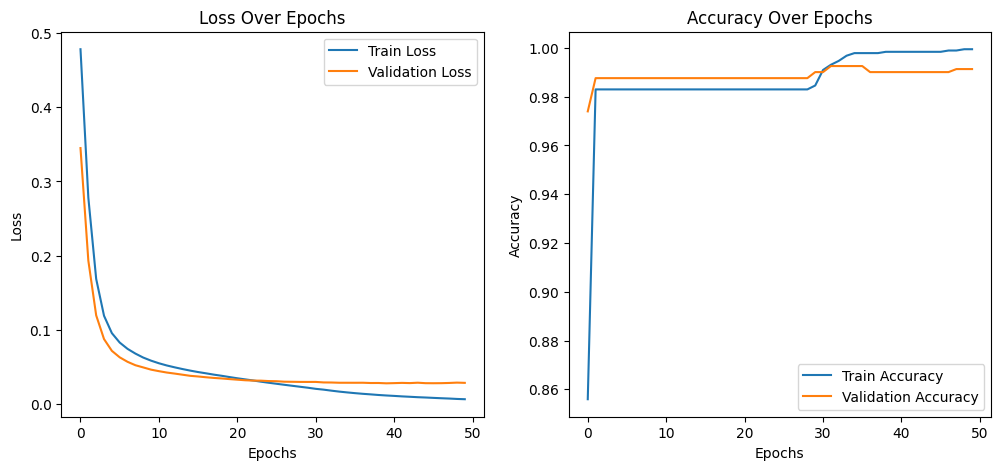

In [176]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [177]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


In [178]:
print("\n--- Evaluation Metrics ---")
print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))


--- Evaluation Metrics ---
Accuracy Score: 0.9913258983890955

Confusion Matrix:
 [[795   2]
 [  5   5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       797
           1       0.71      0.50      0.59        10

    accuracy                           0.99       807
   macro avg       0.85      0.75      0.79       807
weighted avg       0.99      0.99      0.99       807



In [179]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(0.5086533261222282), 1: np.float64(29.390625)}


In [180]:
optimized_model = Sequential()

In [181]:
optimized_model.add(BatchNormalization(input_shape=(X_train.shape[1],)))

optimized_model.add(Dense(units=128, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=64, activation="relu"))
optimized_model.add(Dropout(0.2))
optimized_model.add(BatchNormalization())

optimized_model.add(Dense(units=32, activation="relu"))
optimized_model.add(Dense(units=1, activation="sigmoid"))

/Users/ccatlabuga/Documents/Personal/RNIP/lab1/venv/lib/python3.13/site-packages/keras/src/layers/normalization/batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [182]:
optimized_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_19          │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,113 (51.22 KB)

 Trainable params: 12,701 (49.61 KB)

 Non-trainable params: 412 (1.61 KB)

In [183]:
optimized_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [184]:
optimized_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), class_weight=class_weights_dict)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5928 - loss: 0.5066 - val_accuracy: 0.9058 - val_loss: 0.4718
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7842 - loss: 0.3346 - val_accuracy: 0.9071 - val_loss: 0.3908
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8735 - loss: 0.2121 - val_accuracy: 0.9380 - val_loss: 0.2763
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9054 - loss: 0.1828 - val_accuracy: 0.9504 - val_loss: 0.2105
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9208 - loss: 0.1963 - val_accuracy: 0.9318 - val_loss: 0.2034
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9293 - loss: 0.1152 - val_accuracy: 0.9678 - val_loss: 0.1328
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9548 - loss: 0.1064 - val_accuracy: 0.9814 - val_loss: 0.0982
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9638 - loss: 0.0961 - val_accuracy: 0.9814 - val_loss:

In [185]:
optimized_predictions = (optimized_model.predict(X_test) > 0.5).astype("int32")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [186]:
print("\n--- Optimized Evaluation Metrics ---")
print("Accuracy Score:", accuracy_score(y_test, optimized_predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, optimized_predictions))
print("\nClassification Report:\n", classification_report(y_test, optimized_predictions))


--- Optimized Evaluation Metrics ---
Accuracy Score: 0.9913258983890955

Confusion Matrix:
 [[791   6]
 [  1   9]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       797
           1       0.60      0.90      0.72        10

    accuracy                           0.99       807
   macro avg       0.80      0.95      0.86       807
weighted avg       0.99      0.99      0.99       807

